## 0. Entendimento do Problema

## 1. Setup e Importações

### 1.1 Bibliotecas

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

### 1.2 Datasets

In [8]:
df1 = pd.read_csv('data/Employee-Attrition.csv')

## 2. Limpeza e Tratamento dos Dados

In [9]:
df2 = df1.copy()

## 3. Análise Exploratória dos Dados (EDA)

In [10]:
df3 = df2.copy()

### 3.1 Linhas e Colunas

In [12]:
shape = df3.shape
print(f'Número de linhas: {shape[0]}\nNúmero de colunas: {shape[1]}')

Número de linhas: 1470
Número de colunas: 35


### 3.2 Amostra dos dados

In [13]:
df3.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### 3.3 Tipos de cada coluna

In [14]:
df3.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

### 3.4 Resumo geral

In [15]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### 3.5 Valores nulos

In [16]:
df3.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### 3.6 Linhas duplicadas

In [17]:
df3.duplicated().sum()

np.int64(0)

### 3.7 Cardinalidade de cada coluna

In [24]:
df3.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

### 3.8 Estatísticas numéricas

In [22]:
df3.describe().round(1)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,...,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
mean,36.9,802.5,9.2,2.9,1.0,1024.9,2.7,65.9,2.7,2.1,...,2.7,80.0,0.8,11.3,2.8,2.8,7.0,4.2,2.2,4.1
std,9.1,403.5,8.1,1.0,0.0,602.0,1.1,20.3,0.7,1.1,...,1.1,0.0,0.9,7.8,1.3,0.7,6.1,3.6,3.2,3.6
min,18.0,102.0,1.0,1.0,1.0,1.0,1.0,30.0,1.0,1.0,...,1.0,80.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
25%,30.0,465.0,2.0,2.0,1.0,491.2,2.0,48.0,2.0,1.0,...,2.0,80.0,0.0,6.0,2.0,2.0,3.0,2.0,0.0,2.0
50%,36.0,802.0,7.0,3.0,1.0,1020.5,3.0,66.0,3.0,2.0,...,3.0,80.0,1.0,10.0,3.0,3.0,5.0,3.0,1.0,3.0
75%,43.0,1157.0,14.0,4.0,1.0,1555.8,4.0,83.8,3.0,3.0,...,4.0,80.0,1.0,15.0,3.0,3.0,9.0,7.0,3.0,7.0
max,60.0,1499.0,29.0,5.0,1.0,2068.0,4.0,100.0,4.0,5.0,...,4.0,80.0,3.0,40.0,6.0,4.0,40.0,18.0,15.0,17.0


### 3.9 Estatística categórica

In [23]:
df3.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


### 3.10 Análise do target

In [38]:
df3['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [39]:
df3['Attrition'].value_counts(normalize=True).mul(100).round(1)

Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64

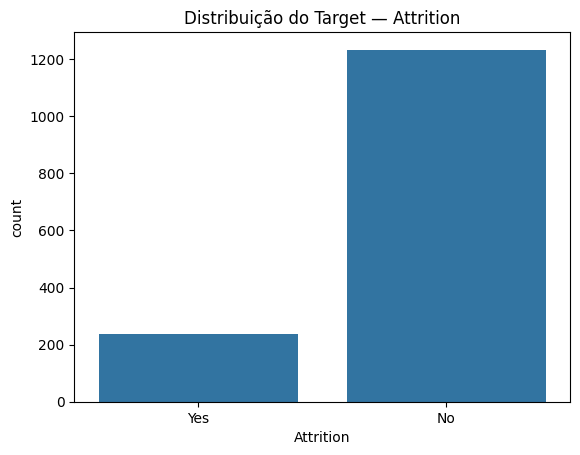

In [40]:
sns.countplot(data=df3, x='Attrition')
plt.title('Distribuição do Target — Attrition')
plt.show()

### 3.11 Análise univariada - variáveis numéricas

In [25]:
numericas = df3.select_dtypes(include='number').columns.tolist()

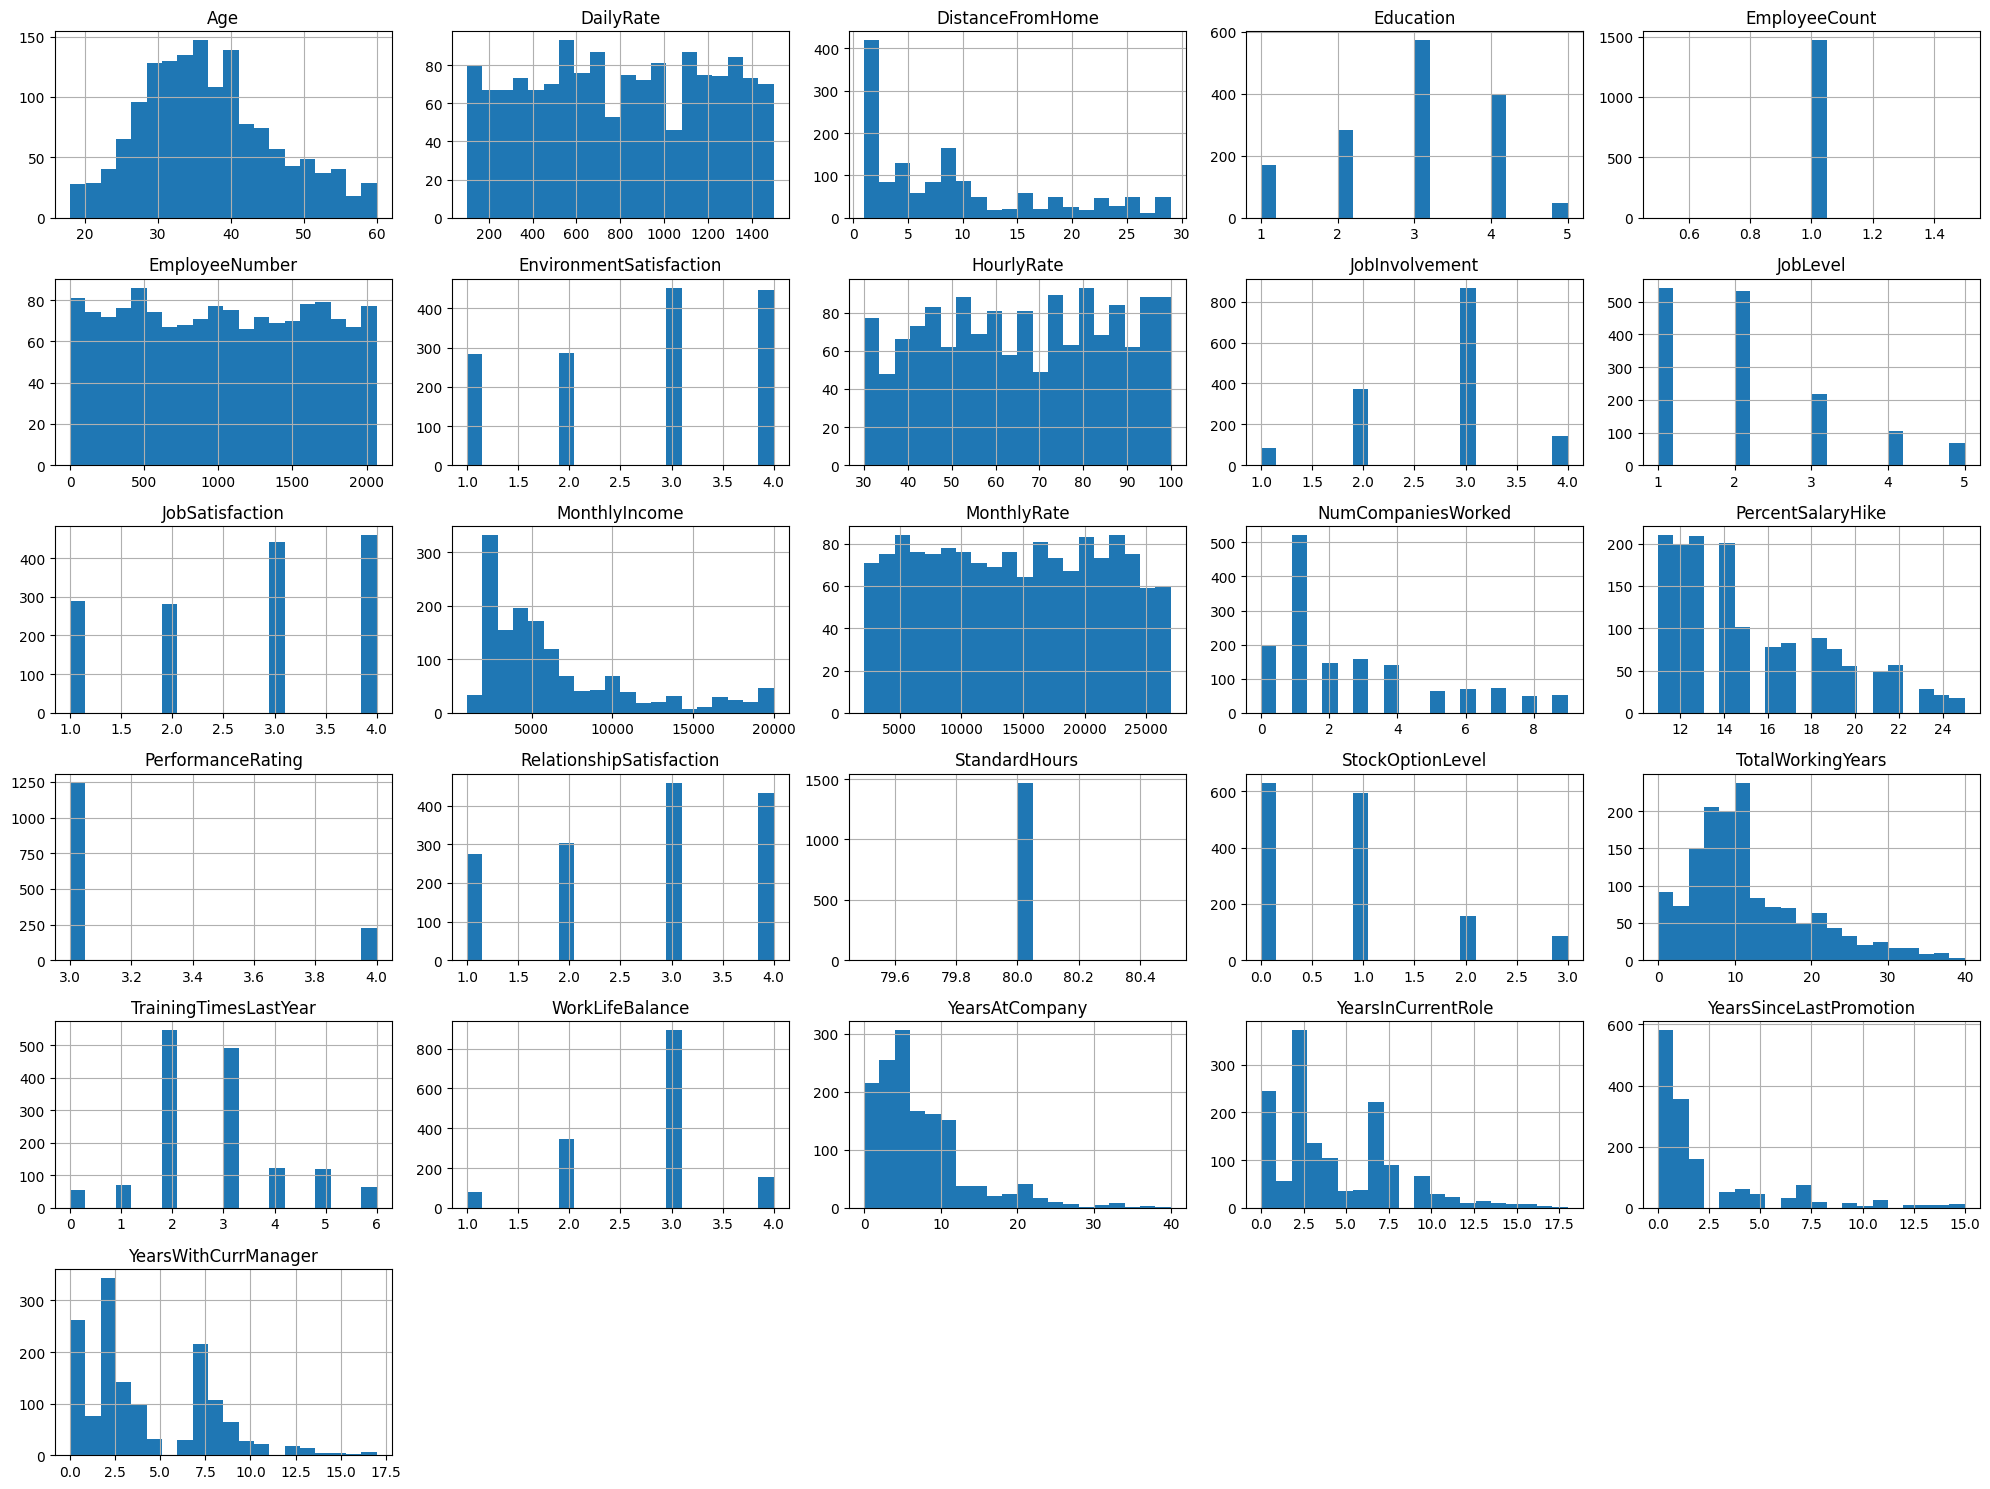

In [27]:
# Histogramas
df3[numericas].hist(figsize=(20,15), bins=20)
plt.tight_layout()
plt.show()

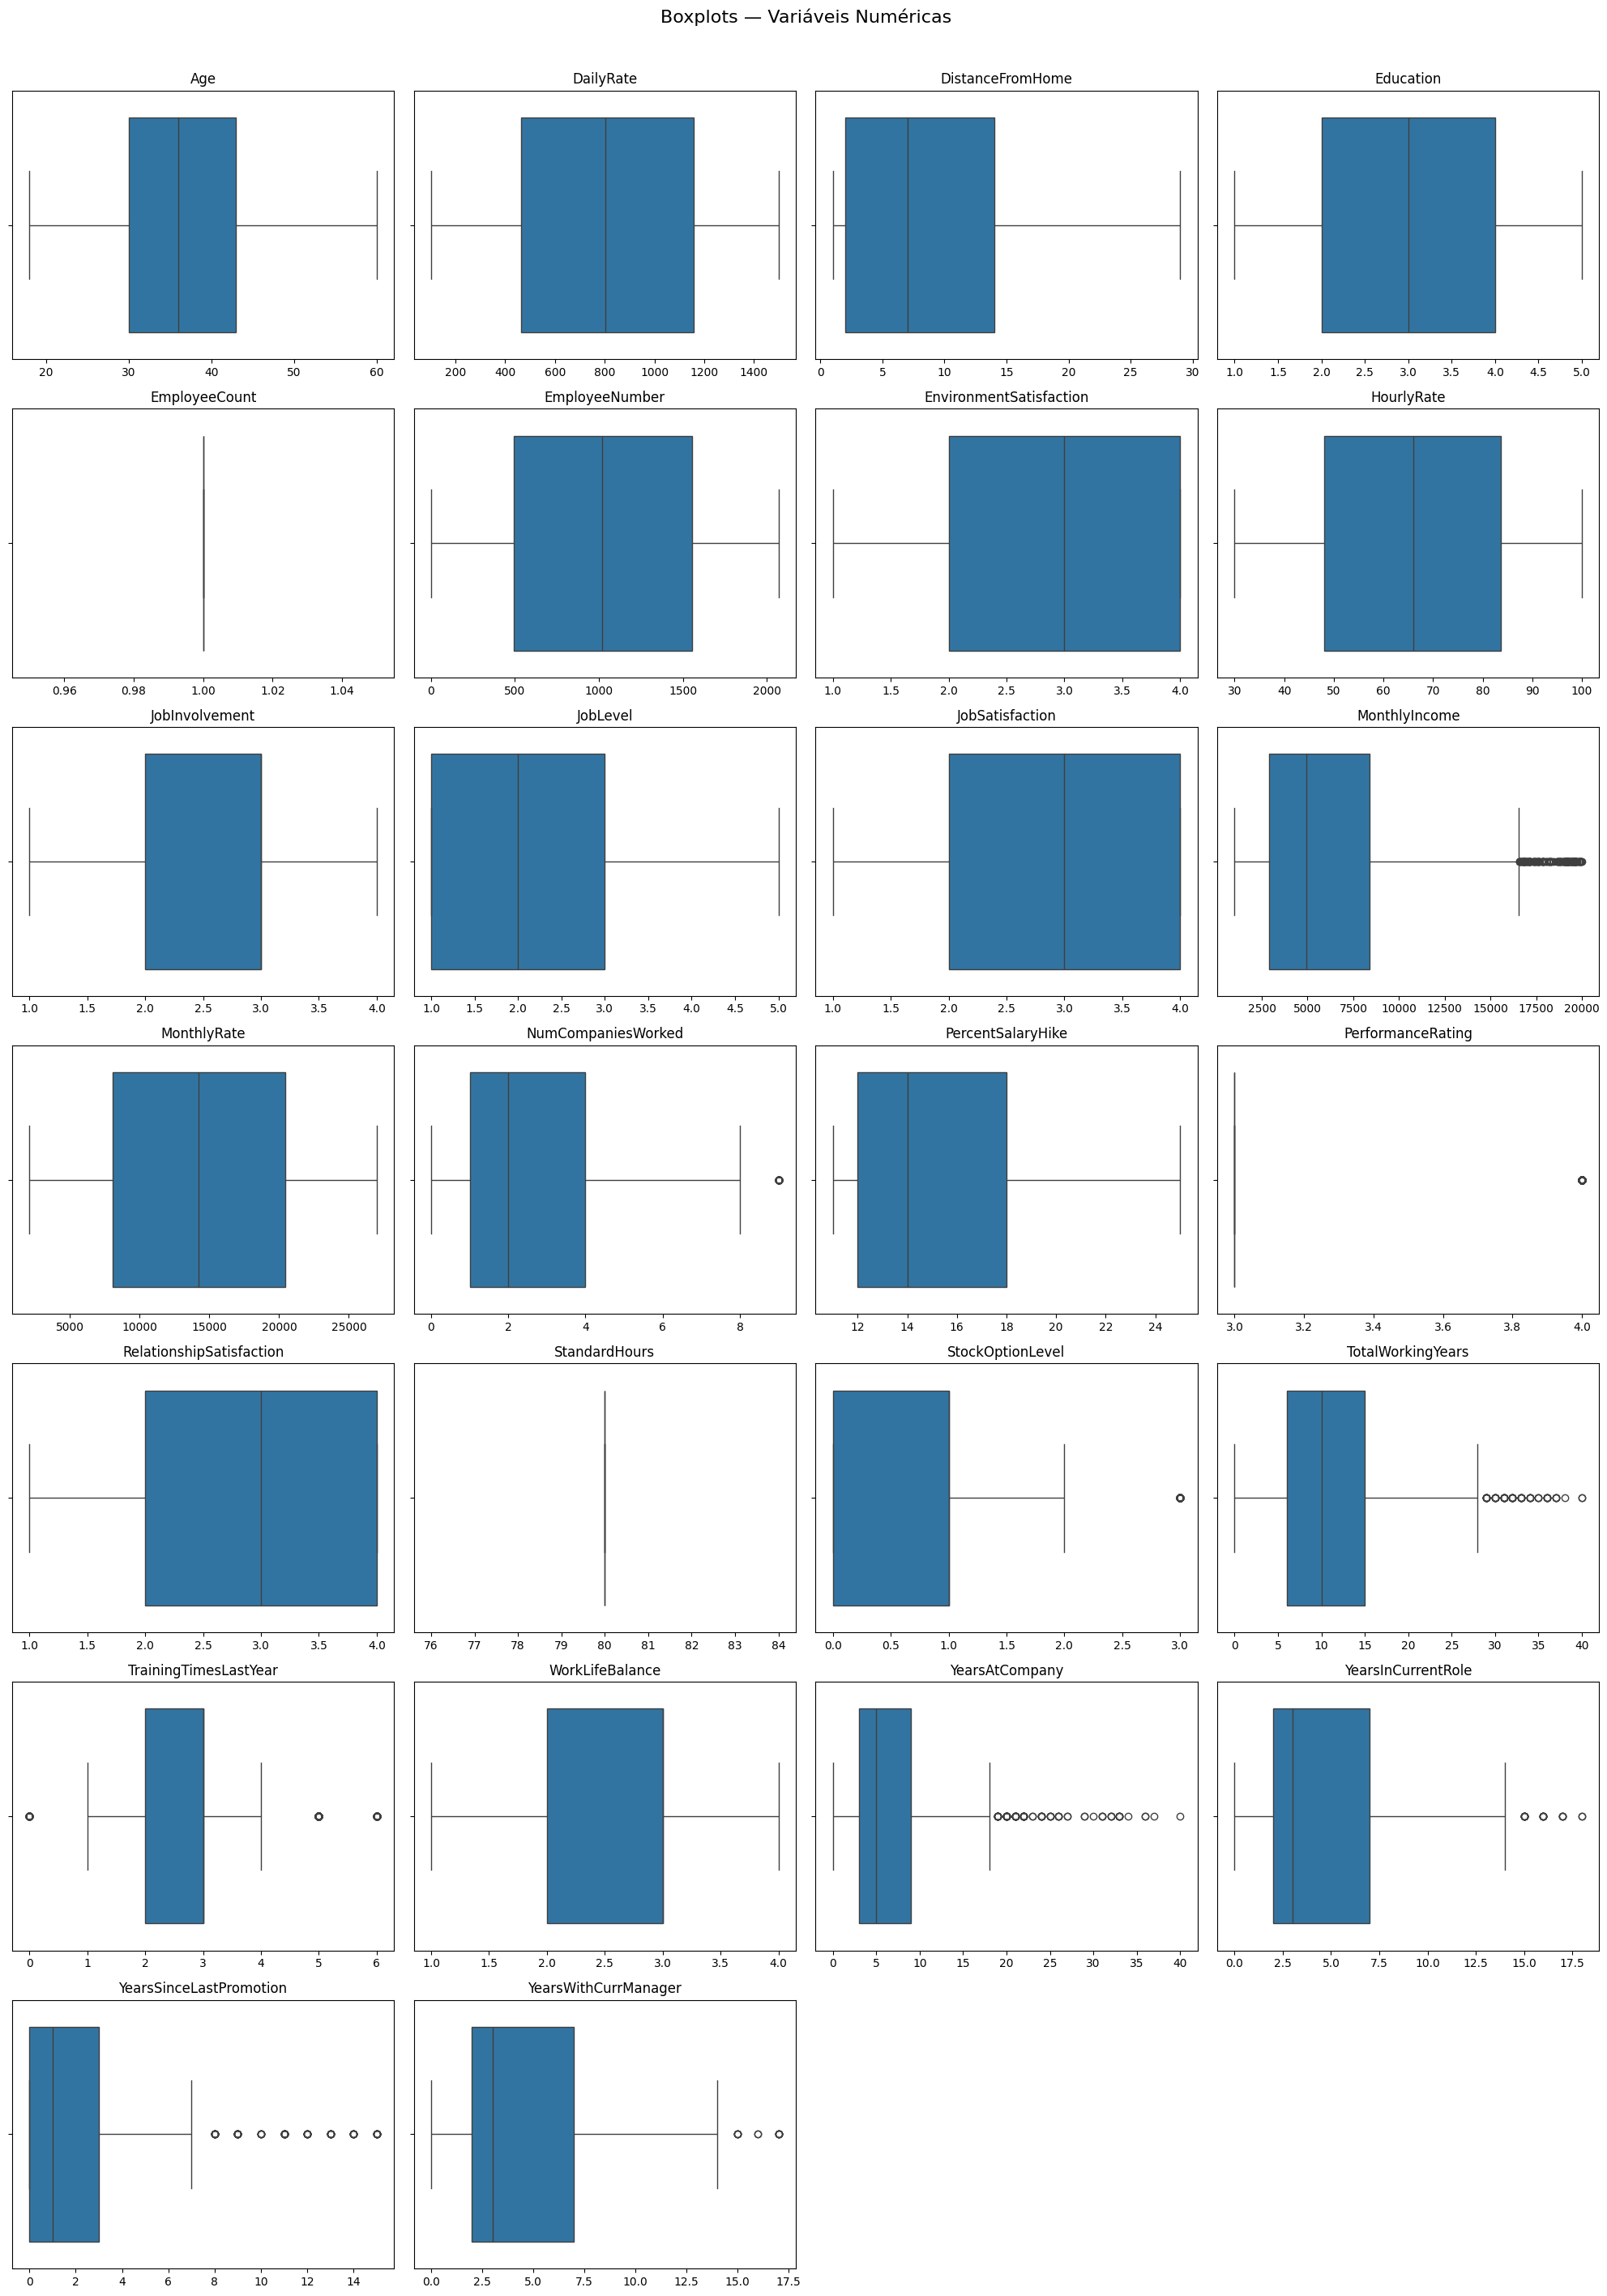

In [ ]:
n_cols = 4
n_rows = math.ceil(len(numericas) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.boxplot(x=df3[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Variáveis Numéricas', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.12 Análise univariada - variáveis categóricas

In [33]:
categoricas = df3.select_dtypes(include='object').columns.tolist()

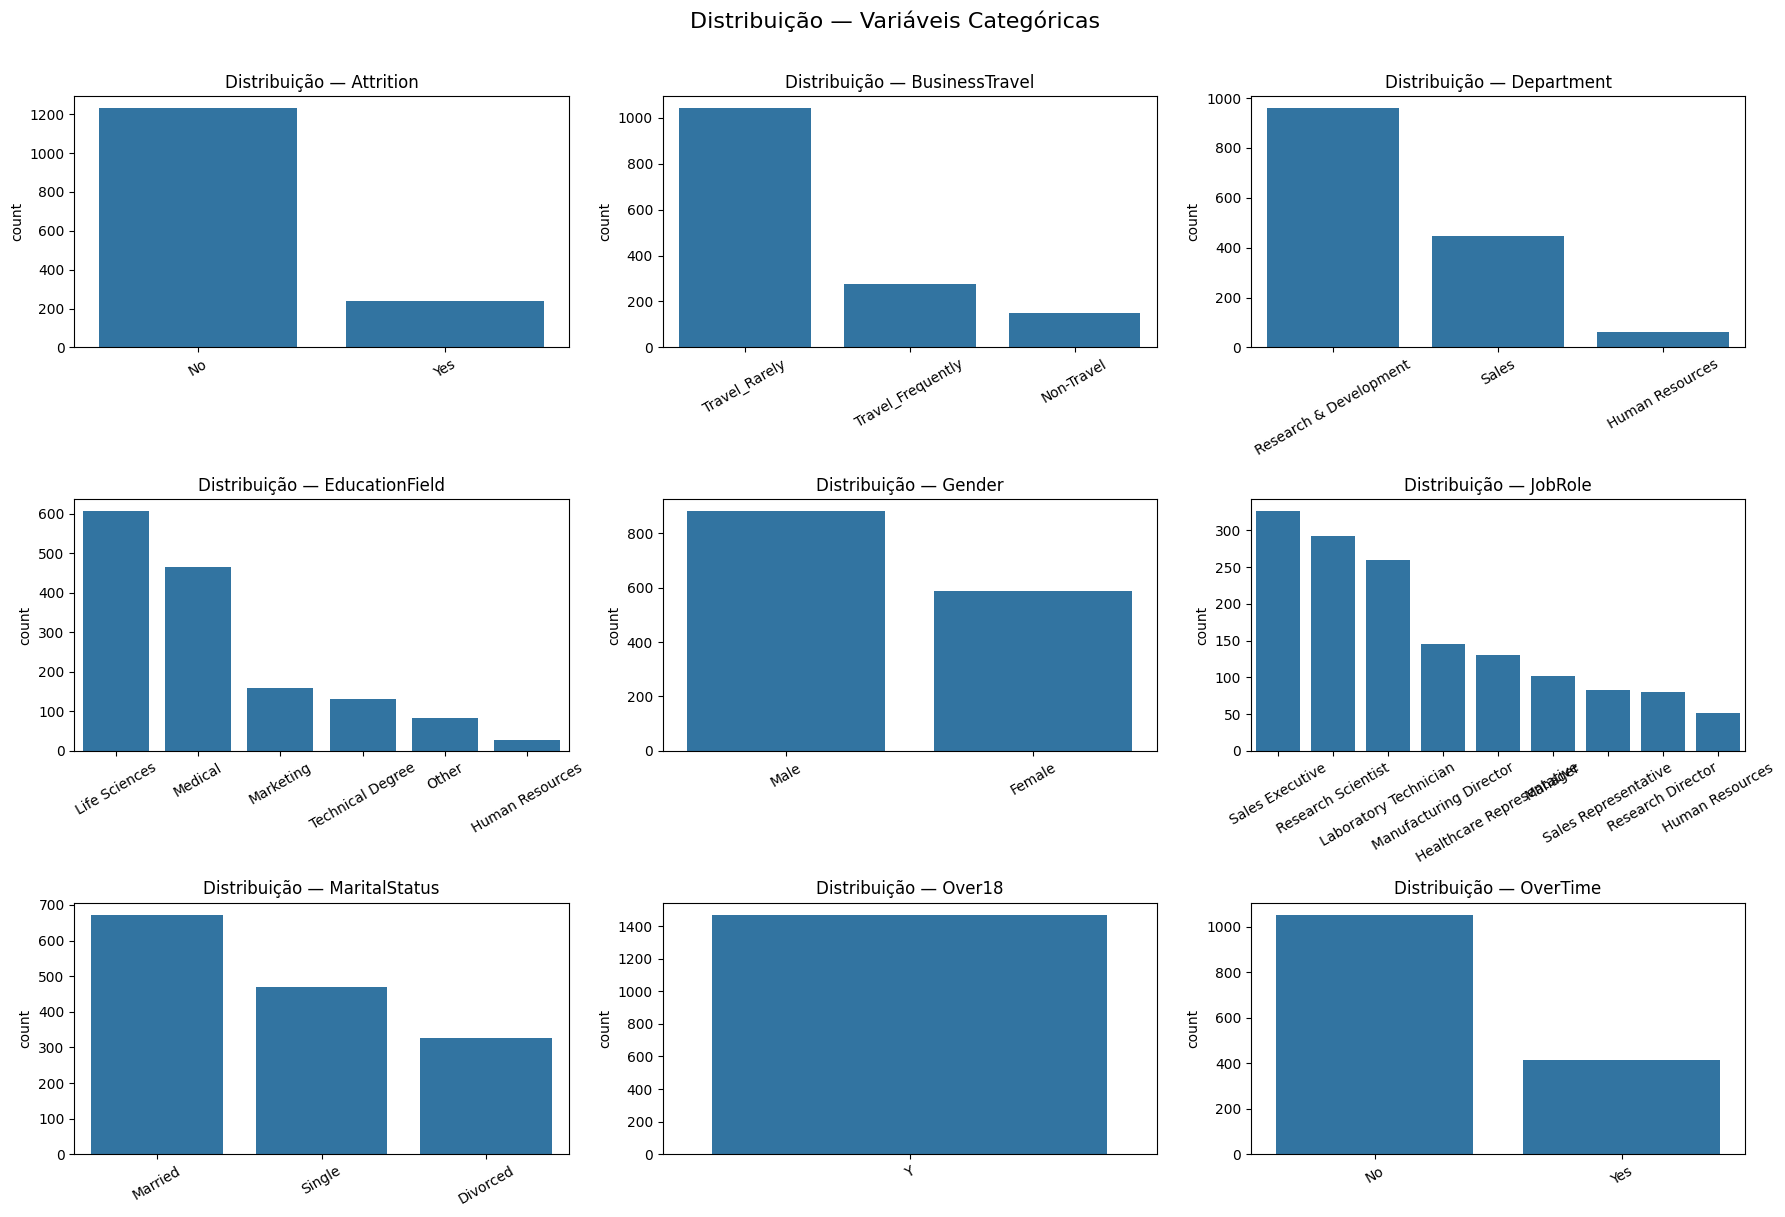

In [35]:
n_cols = 3
n_rows = math.ceil(len(categoricas) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    sns.countplot(data=df3, x=col, order=df3[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Distribuição — {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição — Variáveis Categóricas', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.13 Análise bivariada - categoricas vs target

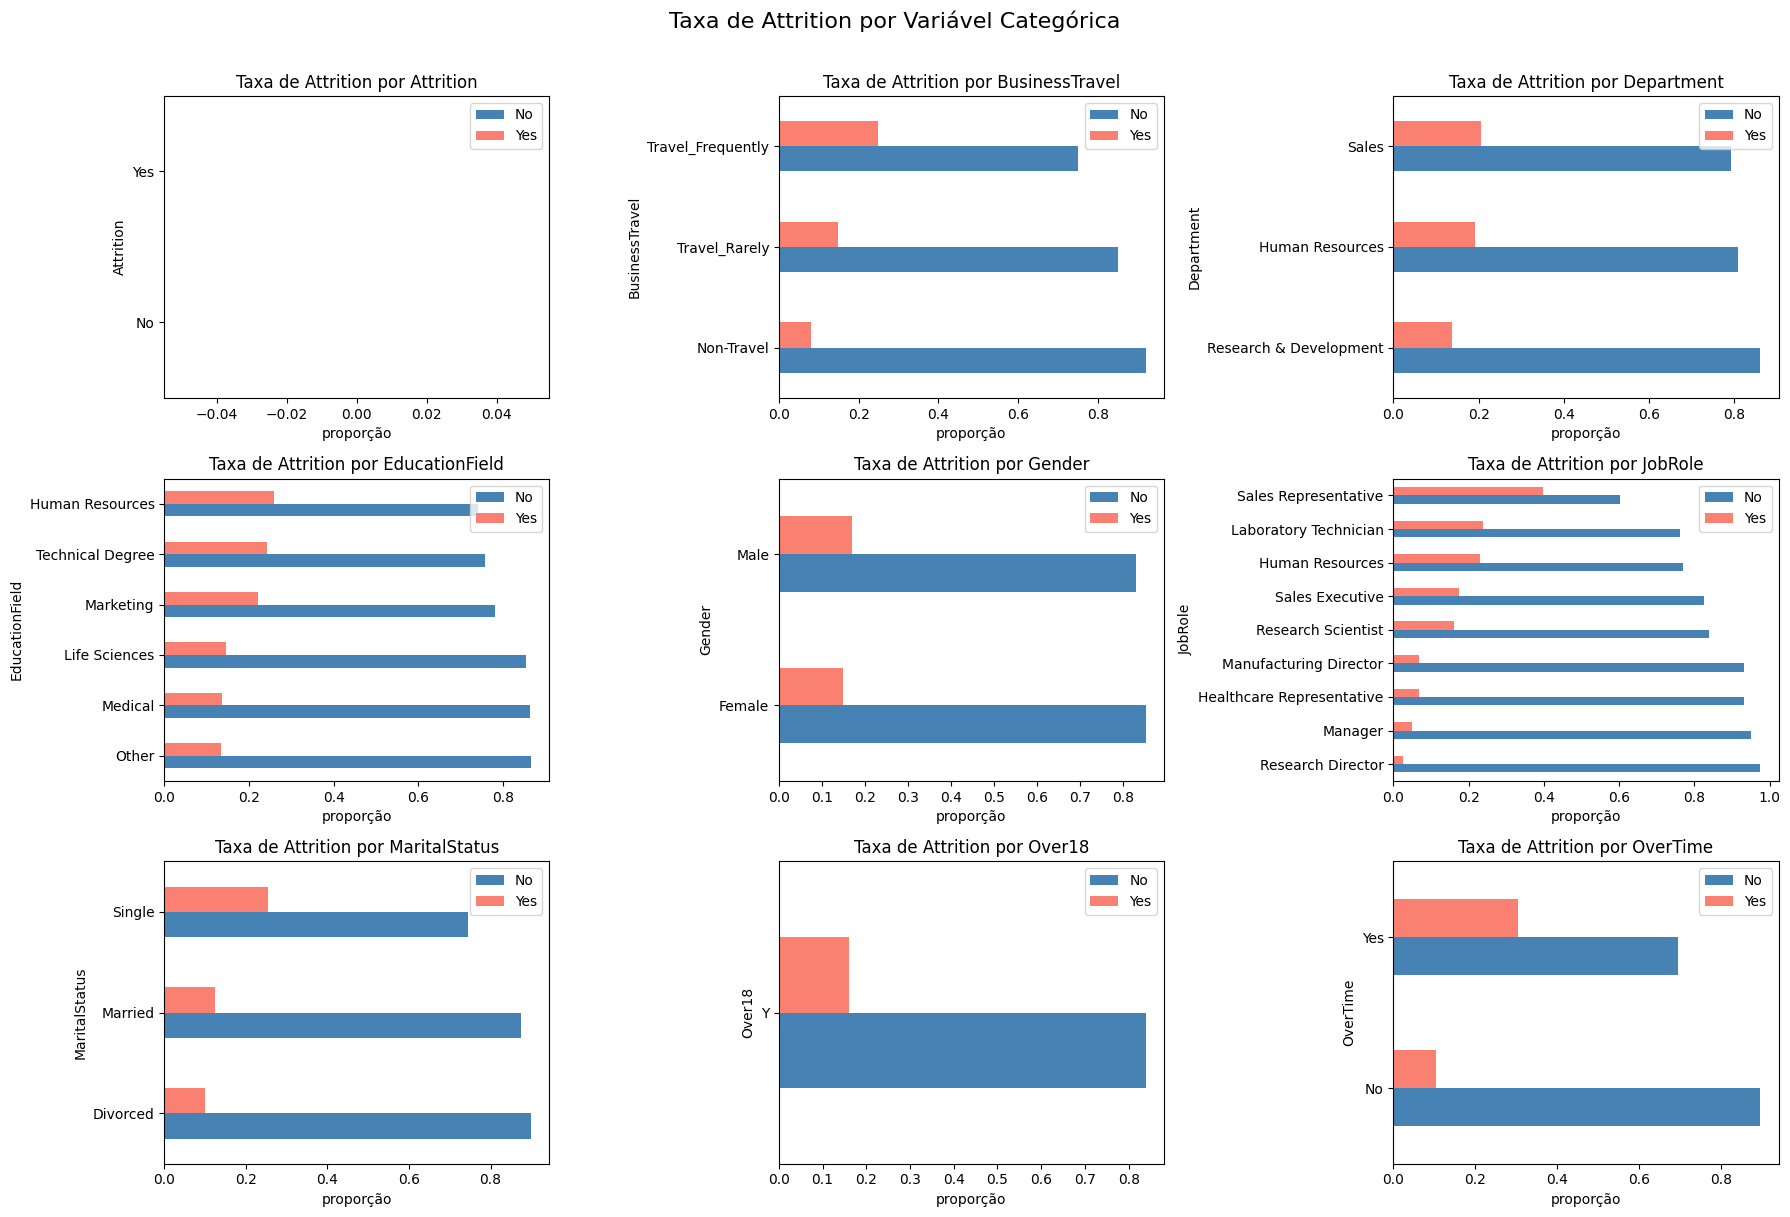

In [47]:
import math

n_cols = 3
n_rows = math.ceil(len(categoricas) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    no  = df3[df3['Attrition'] == 'No'].groupby(col).size()
    yes = df3[df3['Attrition'] == 'Yes'].groupby(col).size()
    total = no + yes
    prop = pd.DataFrame({'No': no / total, 'Yes': yes / total}).sort_values('Yes')
    prop.plot(kind='barh', ax=axes[i], color=['steelblue', 'salmon'])
    axes[i].set_title(f'Taxa de Attrition por {col}')
    axes[i].set_xlabel('proporção')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Taxa de Attrition por Variável Categórica', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.14 Análise bivariada — numericas vs target

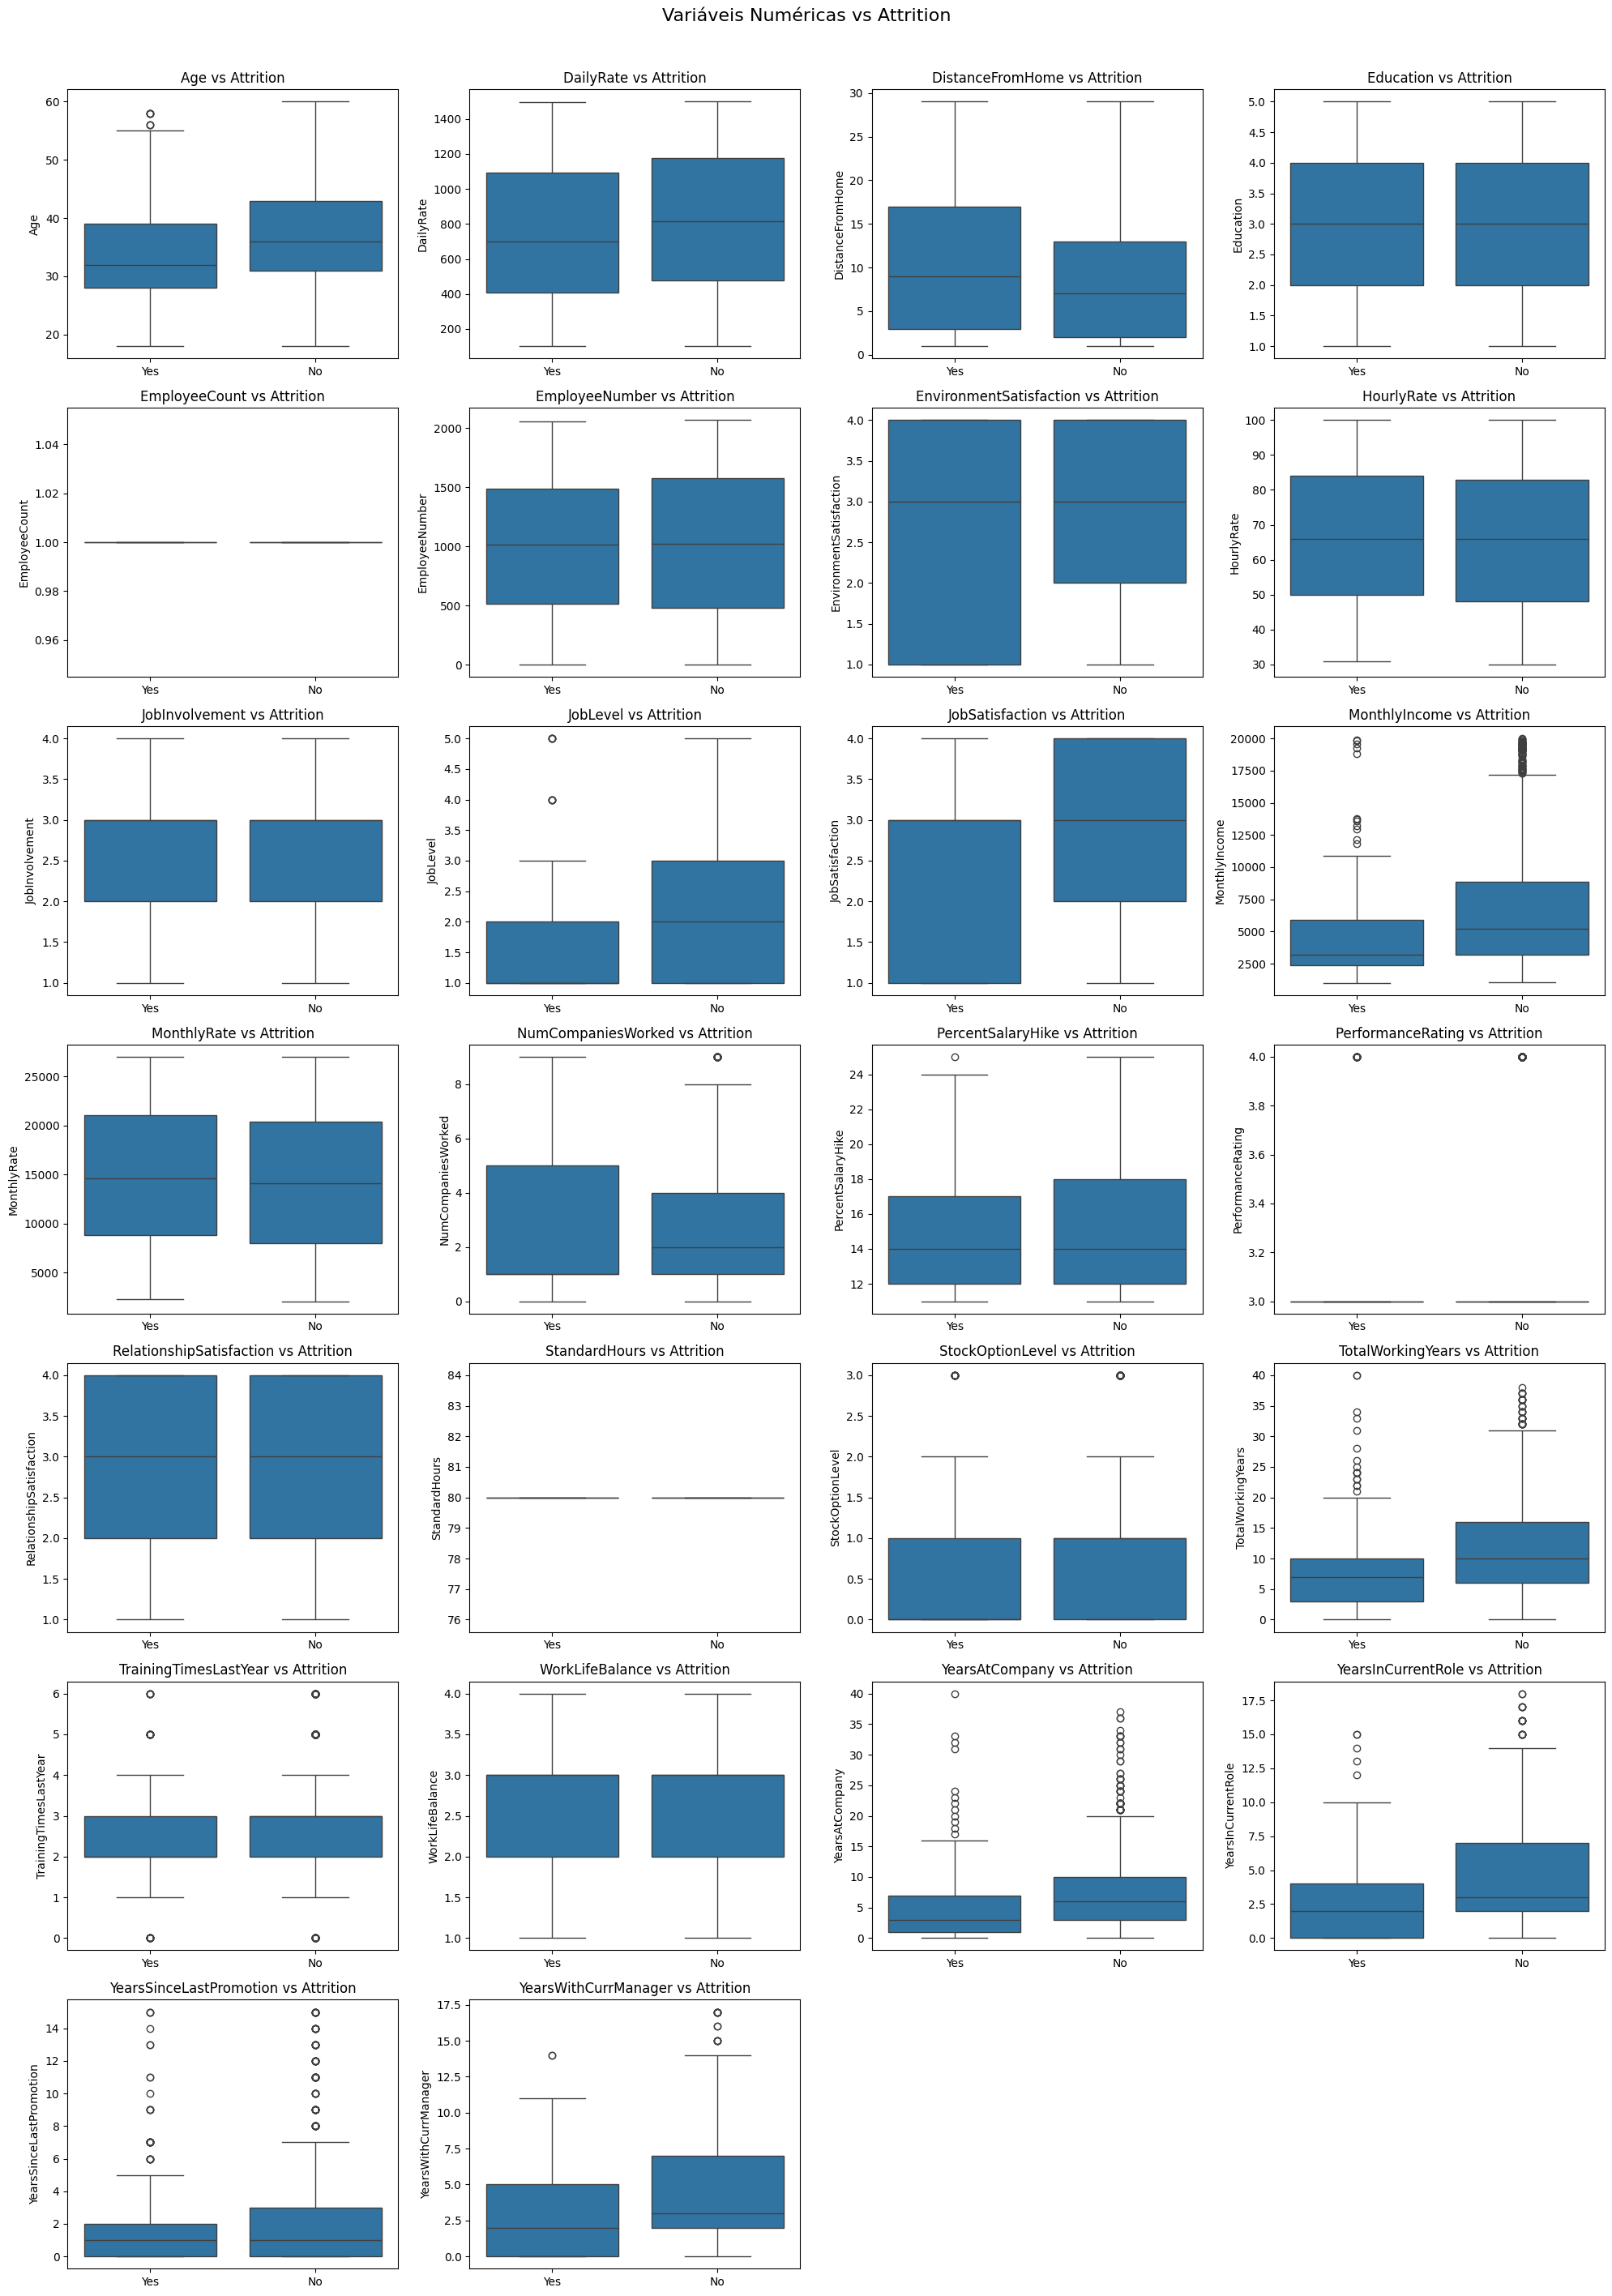

In [49]:
n_cols = 4
n_rows = math.ceil(len(numericas) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.boxplot(data=df3, x='Attrition', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs Attrition')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variáveis Numéricas vs Attrition', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.15 Matriz de correlação

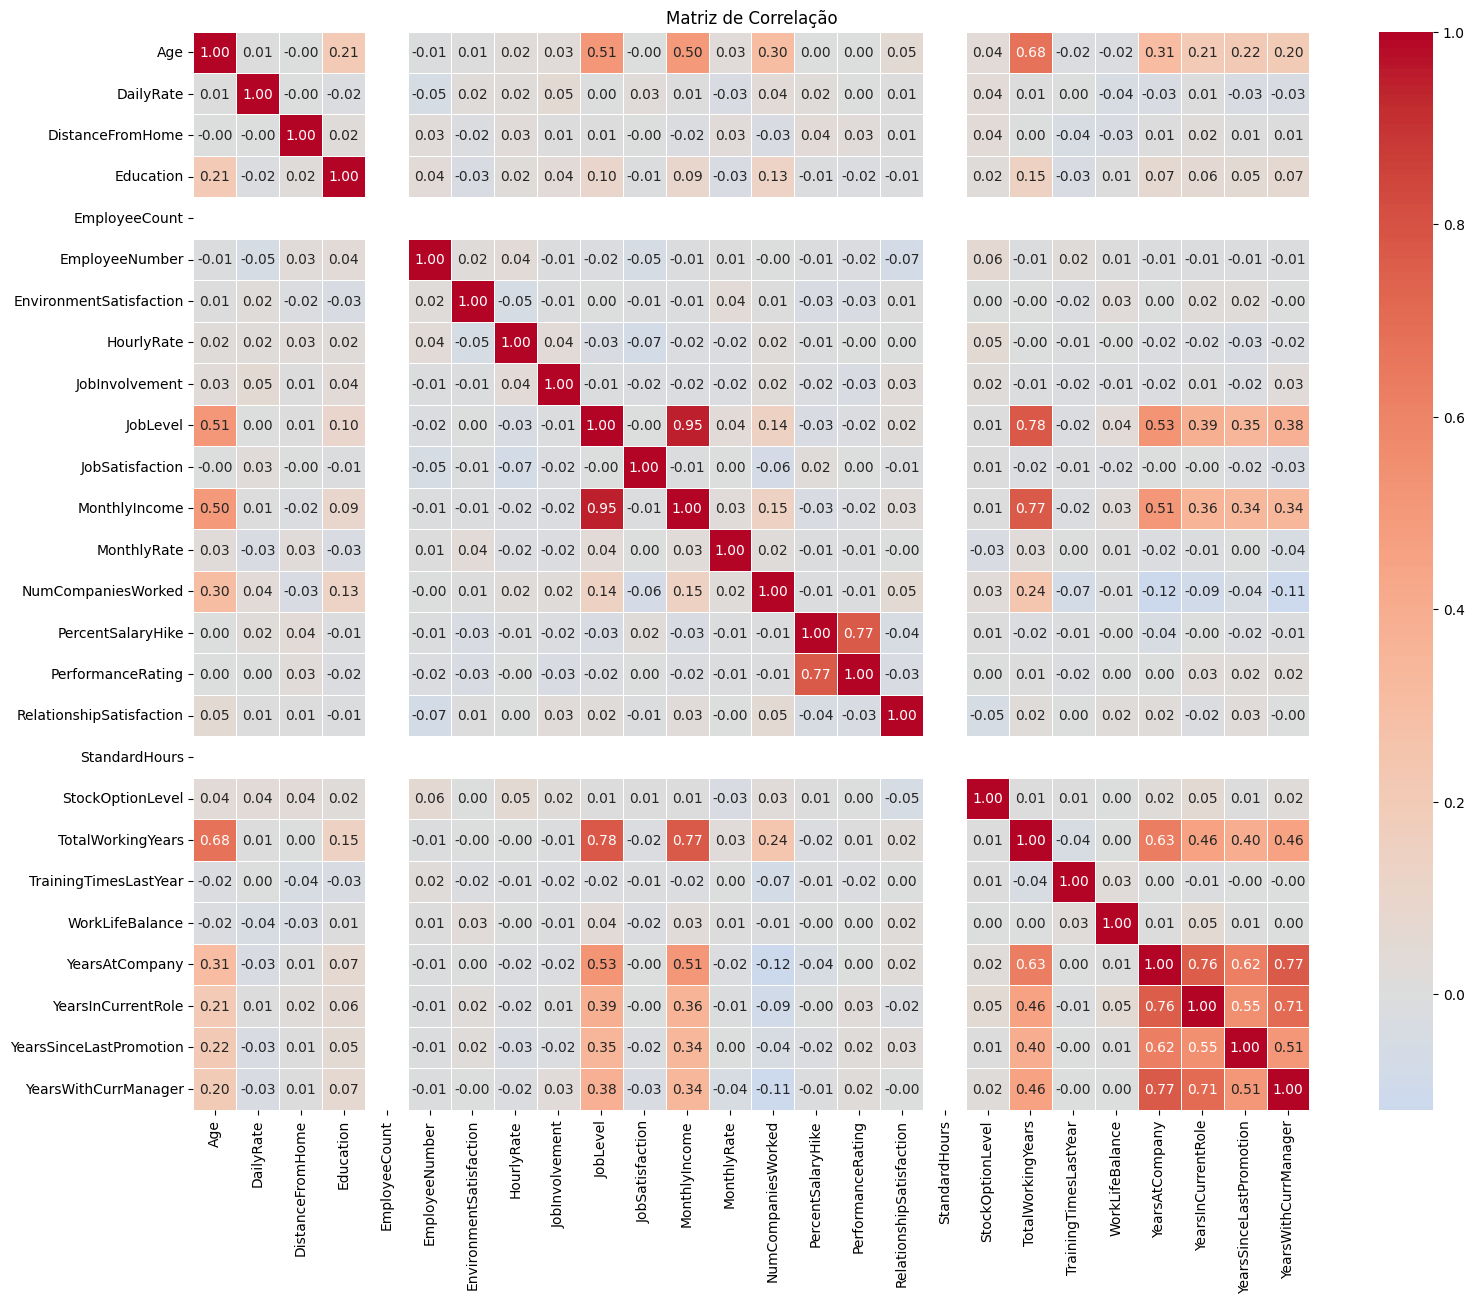

In [51]:
plt.figure(figsize=(18, 14))
sns.heatmap(df3[numericas].corr().round(2),
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5)
plt.title('Matriz de Correlação')
plt.show()

## 4. Engenharia de Atributos (Feature Engineering)

## 5. Encoding de Variáveis Categóricas

## 6. Seleção de Features e Divisão dos Dados

## 7. Treinamento e Comparação de Modelos

## 8. Otimização de Hiperparâmetros

## 9. Avaliação Detalhada do Melhor Modelo

## 10. Interpretabilidade do Modelo

## 11. Persistência e Inferência do Modelo

## 12. Insights e Recomendações de Negócio